## Feature Enginnering

** Adding Libraries and Data we want to parse **

In [2]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import string
import re
import emoji # for counting emojis in each post
cleaned_df=pd.read_csv('mental_health_cleaned.csv')
cleaned_df


,text,label,source
0,a question about the third conditional. i was ...,NaN,Murarka
1,the epitome of my life i've recently requested...,ADHD,Murarka
2,what are your favourites offbeat destinations ...,NaN,Murarka
3,synesthesia survey (what colour is each month ...,NaN,Murarka
4,"science ama series: i’m phil baran, and i’m he...",NaN,Murarka
...,...,...,...
64979,Anxiety cause faintness when standing up ? As ...,Anxiety,Sarkar
64980,anxiety heart symptom does anyone else have th...,Anxiety,Sarkar
64981,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety,Sarkar
64982,fomo from things i’m not involved in does anyo...,Anxiety,Sarkar


**Calculating Post Length AND char Count**
then add it as col to the data frame 

In [3]:
cleaned_df['Post_length'] = cleaned_df['text'].apply(lambda x: len(str(x).split()))
cleaned_df['Char_count'] = cleaned_df['text'].str.len()
cleaned_df

,text,label,source,Post_length,Char_count
0,a question about the third conditional. i was ...,NaN,Murarka,79,457
1,the epitome of my life i've recently requested...,ADHD,Murarka,143,735
2,what are your favourites offbeat destinations ...,NaN,Murarka,460,3085
3,synesthesia survey (what colour is each month ...,NaN,Murarka,195,1164
4,"science ama series: i’m phil baran, and i’m he...",NaN,Murarka,338,2048
...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As ...,Anxiety,Sarkar,23,130
64980,anxiety heart symptom does anyone else have th...,Anxiety,Sarkar,61,306
64981,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety,Sarkar,159,851
64982,fomo from things i’m not involved in does anyo...,Anxiety,Sarkar,172,891


## Calculation Density of Punctuations and Emojis
there are amount of emojisa and punctuations existed in each post which can highlight a chance of underlying **MENTAL HEALTH ISSUE**

In [4]:
cleaned_df['Count_?'] = cleaned_df['text'].str.count(re.escape('?')).fillna(0).astype(int)# if posts are free of any punctuations return 0
cleaned_df['Count_!'] = cleaned_df['text'].str.count(re.escape('!')).fillna(0).astype(int)
##counting emojis in each post 
cleaned_df['Count_emoji'] = cleaned_df['text'].apply(lambda x: 0 if pd.isna(x) else emoji.emoji_count(str(x)))
cleaned_df

,text,label,source,Post_length,Char_count,Count_?,Count_!,Count_emoji
0,a question about the third conditional. i was ...,NaN,Murarka,79,457,2,0,0
1,the epitome of my life i've recently requested...,ADHD,Murarka,143,735,0,0,0
2,what are your favourites offbeat destinations ...,NaN,Murarka,460,3085,1,0,0
3,synesthesia survey (what colour is each month ...,NaN,Murarka,195,1164,2,1,0
4,"science ama series: i’m phil baran, and i’m he...",NaN,Murarka,338,2048,0,2,0
...,...,...,...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As ...,Anxiety,Sarkar,23,130,3,0,0
64980,anxiety heart symptom does anyone else have th...,Anxiety,Sarkar,61,306,4,0,0
64981,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety,Sarkar,159,851,2,1,0
64982,fomo from things i’m not involved in does anyo...,Anxiety,Sarkar,172,891,3,0,0


## VADER SCORING
The **VADER LIB** is a great tool that helps us parse the text and findout about compund score. this score is between -1 to 1 which closer to negative side means the text imperssion is negaitve while as it get closer to positive side it shows more satisfaction we can use this score in trainning our model 

In [5]:
analyzer = SentimentIntensityAnalyzer() ##intiliazing Analyzer 
cleaned_df['Vader_variable'] = cleaned_df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound']) ## add the col to the data frame
cleaned_df

,text,label,source,Post_length,Char_count,Count_?,Count_!,Count_emoji,Vader_variable
0,a question about the third conditional. i was ...,NaN,Murarka,79,457,2,0,0,0.5799
1,the epitome of my life i've recently requested...,ADHD,Murarka,143,735,0,0,0,0.3875
2,what are your favourites offbeat destinations ...,NaN,Murarka,460,3085,1,0,0,0.9997
3,synesthesia survey (what colour is each month ...,NaN,Murarka,195,1164,2,1,0,0.8904
4,"science ama series: i’m phil baran, and i’m he...",NaN,Murarka,338,2048,0,2,0,0.9922
...,...,...,...,...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As ...,Anxiety,Sarkar,23,130,3,0,0,-0.4479
64980,anxiety heart symptom does anyone else have th...,Anxiety,Sarkar,61,306,4,0,0,0.9190
64981,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety,Sarkar,159,851,2,1,0,-0.9585
64982,fomo from things i’m not involved in does anyo...,Anxiety,Sarkar,172,891,3,0,0,0.9140


##  Export 
the following calculations will be shared with other teammates to start next part of project which is trainning model to identify mental health issues

In [7]:
cleaned_df.to_csv('mental_health_engineered.zip', index=False, compression='zip') ##since file size is bigger than 25 MB

## Analysis of Word distrbution 

We are looking to see if there are any direct connection between length of each person text and the **Mental Health Issue**  they are suffering

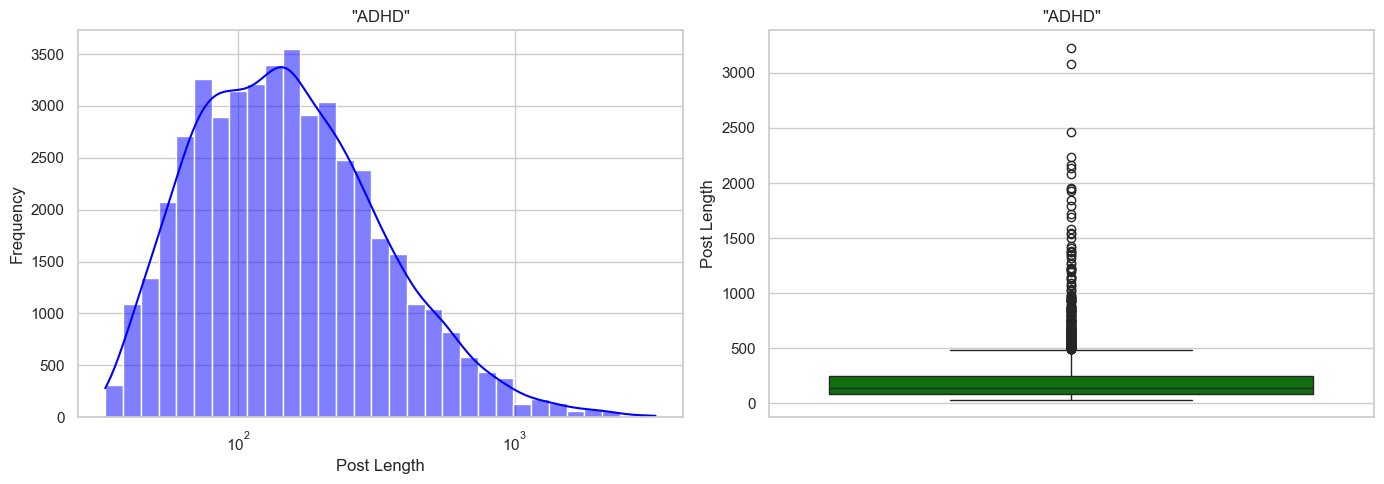

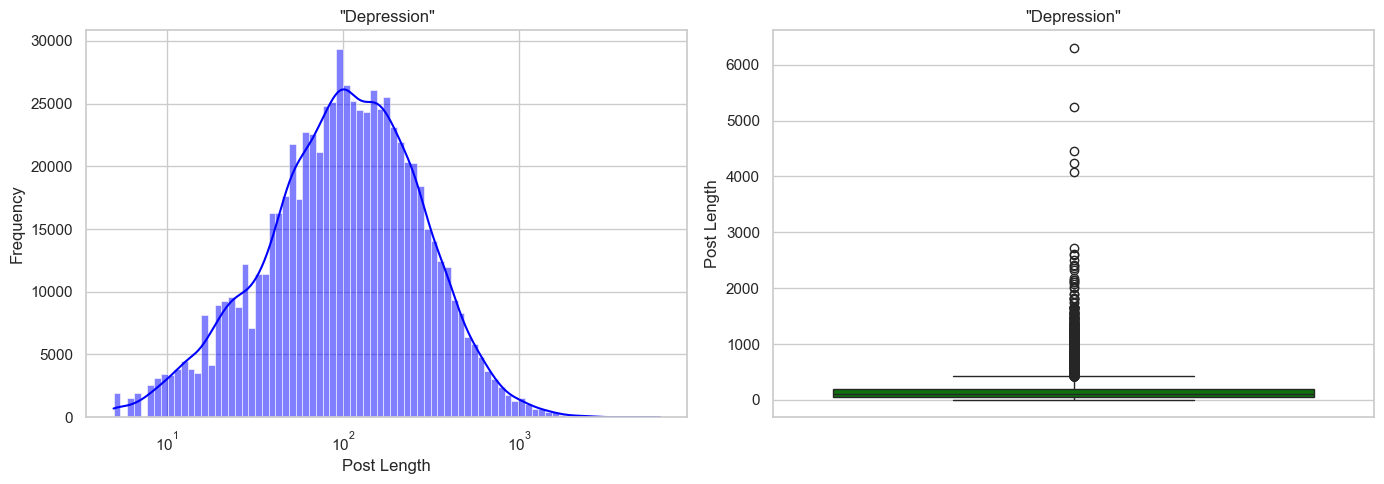

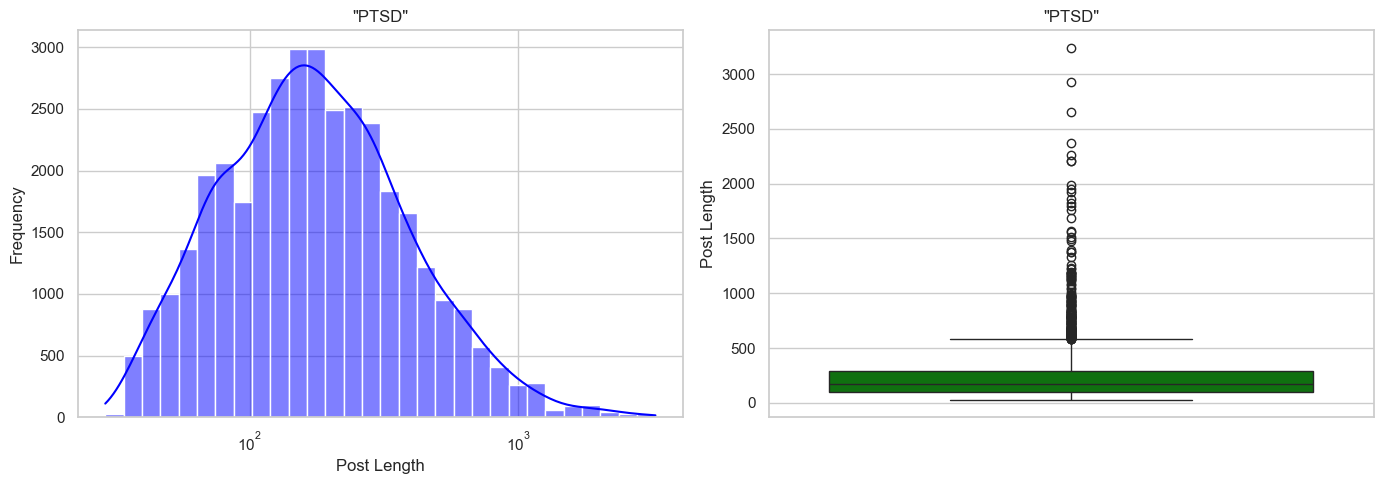

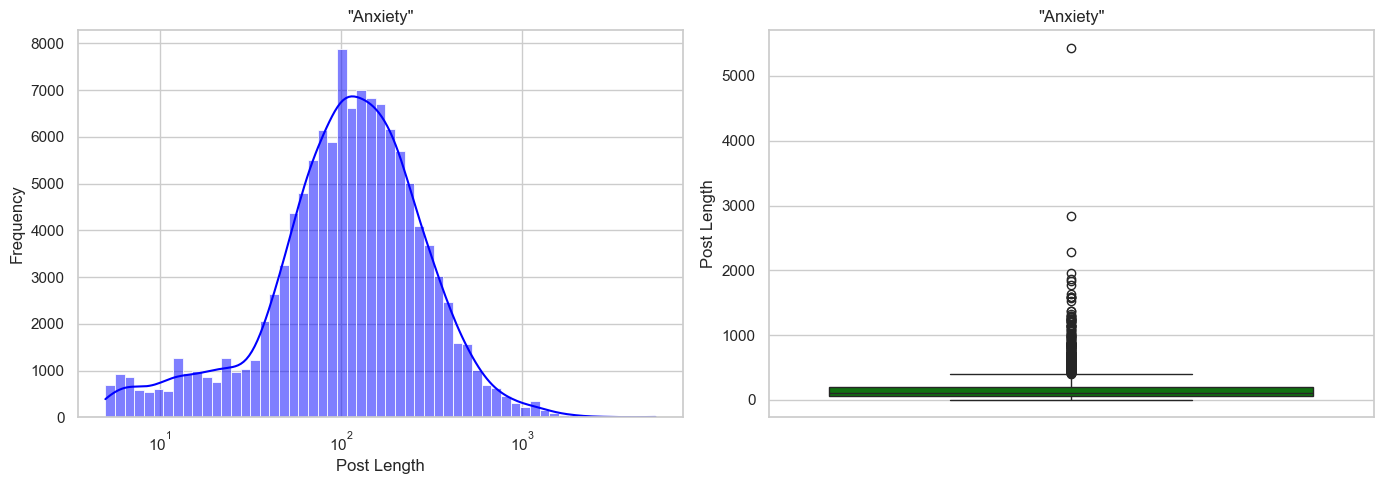

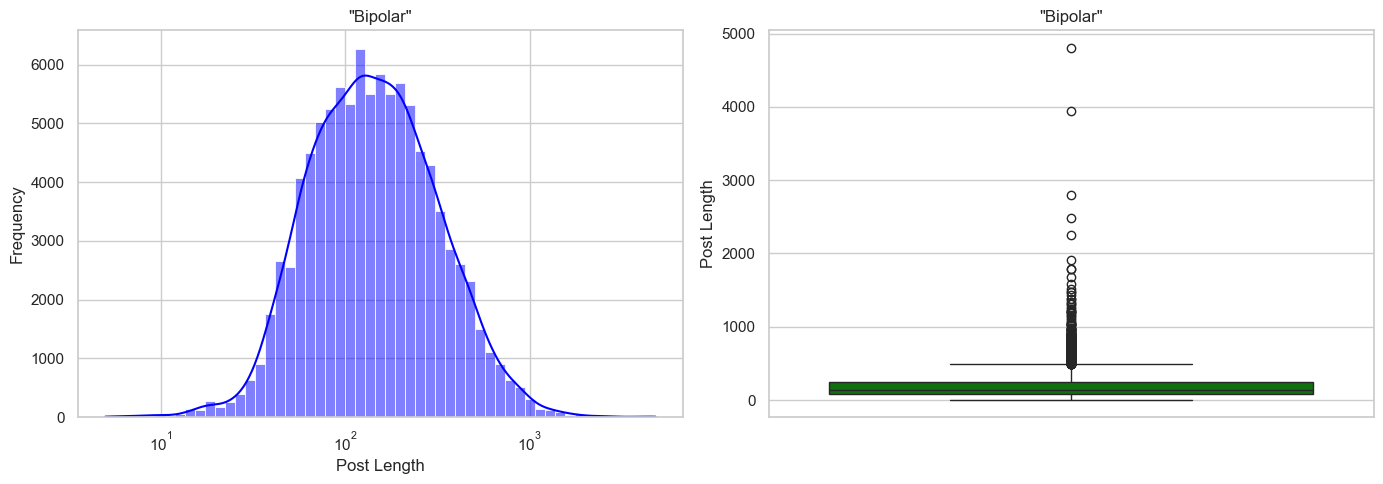

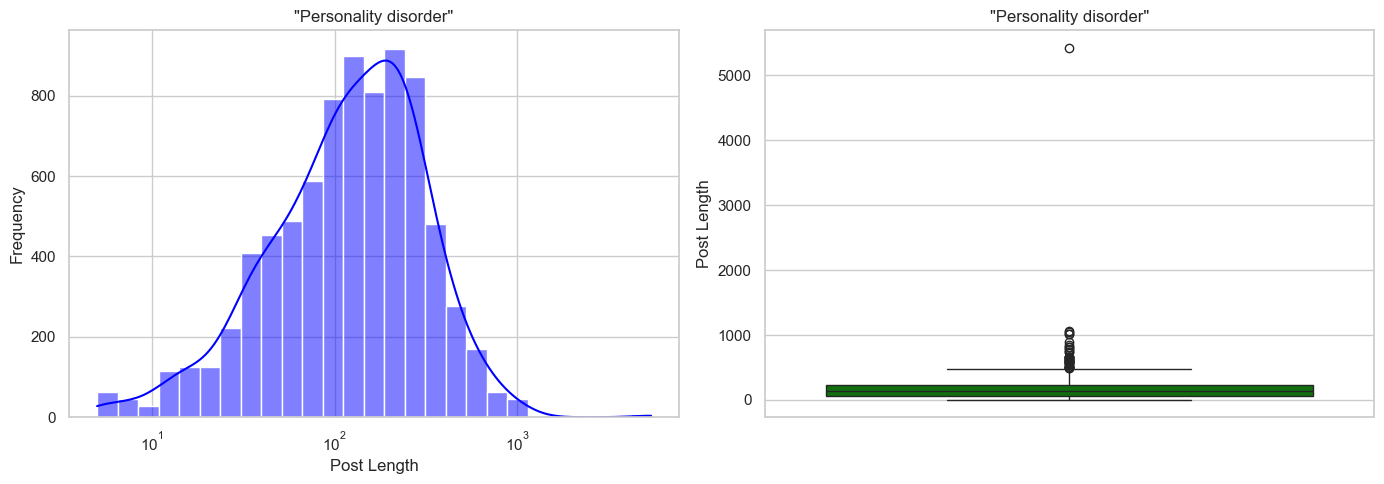

In [6]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid")

visual_df = cleaned_df.dropna(subset=['label', 'Post_length']).copy()
unique_labels = visual_df['label'].unique()

for label in unique_labels:
    subset_df = visual_df[visual_df['label'] == label]  
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
    
    # Histogram
    sb.histplot(
        data=subset_df, 
        x='Post_length', 
        kde=True, 
        ax=axes[0], 
        color='blue',
        stat='frequency', #  we want to plot based on numbers we have
        log_scale=True # to also show frequency on X axis
    )    
    axes[0].set_title(f'"{label}"')
    axes[0].set_xlabel('Post Length')
    
    # Boxplot 
    sb.boxplot(data=subset_df, y='Post_length', ax=axes[1], color='Green')
    axes[1].set_title(f'"{label}"')
    axes[1].set_ylabel('Post Length')
    
    plt.tight_layout()
    plt.show()

## Interpertation of the results
As I reviewed the the result I noticed patterns that are connected in some ways to the type of disorder each patient is dealing with:

## ADHD
People with ADHD disorder tend to have short focus so their posts, brief, punchy posts. The absolute longest post in this category is around 3000 words, which is actually one of the shortest maximum lengths among all your categories.
## DEPRESSION
This class is highly varied. You have a huge number of very short posts (people perhaps just dropping a quick, one-sentence thought or title), but you also have the most extreme outliers in your entire dataset. Users here are occasionally writing massive, diary-like entries to vent.
## PTSD
This category posts are slightly longer and more detailed on average than others . They don't quite reach the extreme 6,000-word lengths of the Depression category, but the baseline patient tends to write a bit more context.
## ANXIETY
The core behavior here perfectly mirrors the overall dataset: quick, 100-word thoughts make up the vast majority, but there is a very strong, consistent habit of users writing highly detailed, lengthy explanations of their anxious experiences.
## BIPOLAR
very similar to **ANXIETY** category. There are no massive surprises here; it represents a healthy, expected distribution of internet forum text data.
## PERSONALITY DISORDER
Because the peak is shifted right, Patients who suffer from **PERSONALITY DISORDER** tend to write the longest "average" posts in the dataset. They are less likely to write quick 50-word blurbs and more likely to write 200-300 word explanations. 

## VADER SCORE ANALYSIS
AS mentioned earlier about what is Vader and how it works we want to analyze if each type of disorder have unique version of score 

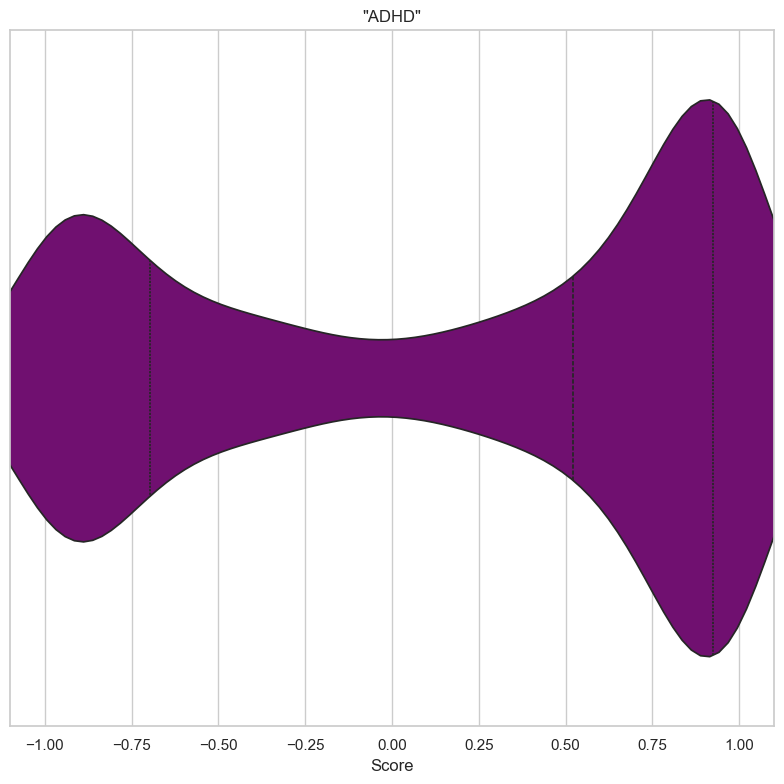

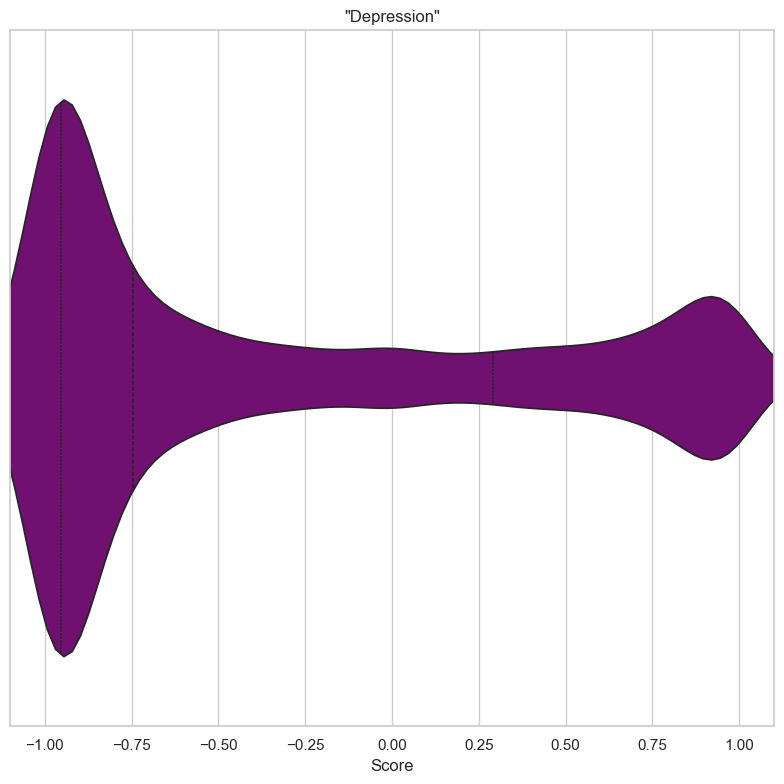

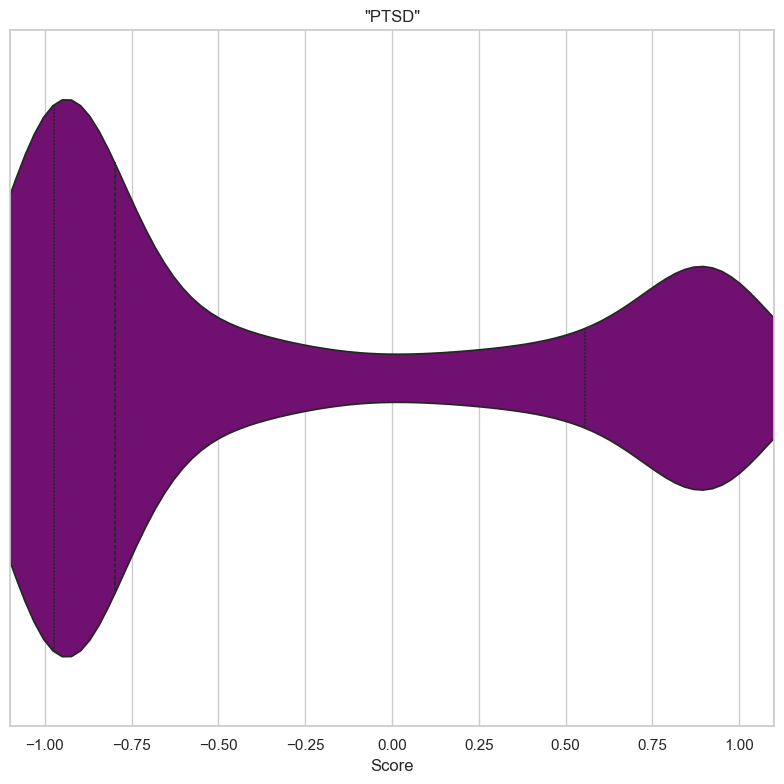

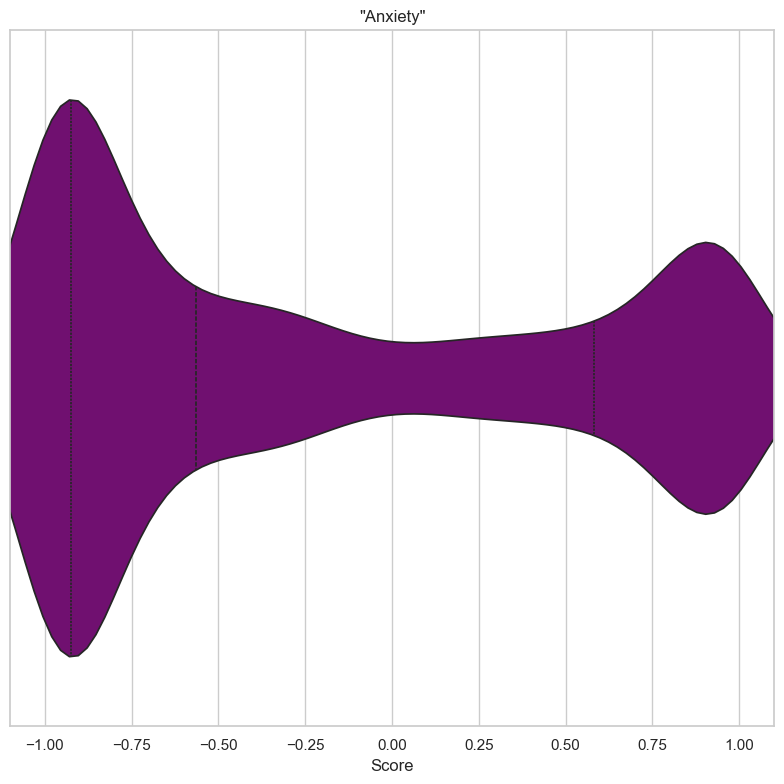

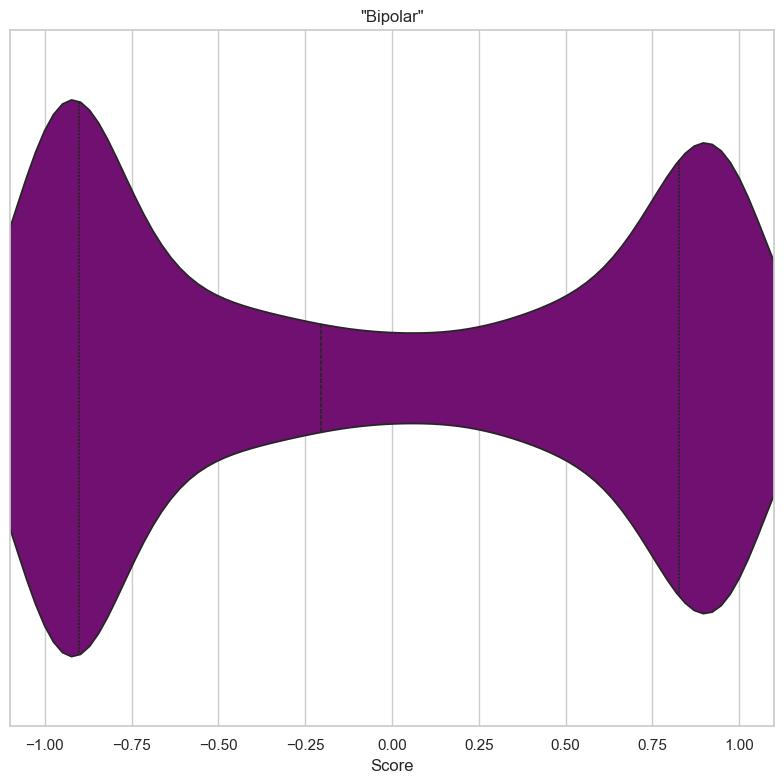

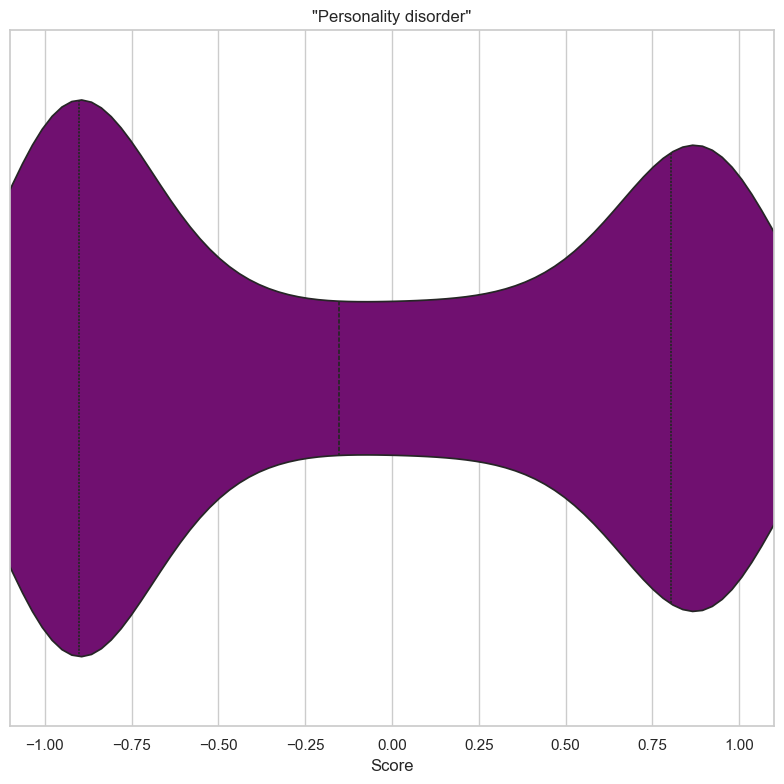

In [ ]:
for label in unique_labels:
    subset_df = cleaned_df[cleaned_df['label'] == label] 
    plt.figure(figsize=(8, 8))
    
    sb.violinplot(# violin plot
        data=subset_df, 
        x='Vader_variable',       
        color='purple',  
        inner='quartile'       # Show the median and middle lines inside
    )
    
    plt.title(f'"{label}"')
    plt.xlabel('Score')
    plt.xlim(-1.1, 1.1) # Locking X axis for simpler comparision 
    
    plt.tight_layout()
    plt.show()

## Interpertation of VADER SCORE
based on analyzing the violin Plots I have filtered each disorder based on 3 categories:

## The Heavily Negative (Depression, PTSD, Anxiety)
bulk of each patient post were heavily scored negative.While there is a small bump of positive posts on the far right (likely supportive comments or "I finally feel better" posts), the overwhelming baseline language used in these communities is highly distressed, sad, or fearful.this group of Patients need care and support more than other two groups

## The Truly Polarized (Bipolar, Personality Disorder)
The perfect hourglass which shows that distrubtuion is balanced and equal on both side. The language in these forums is intensely emotionally charged in both directions. You have an almost equal number of highly distressed posts and highly energetic/positive posts. (Note: This perfectly mirrors the clinical reality of Bipolar disorder, showing that your text data is accurately capturing the nature of the condition!)

## The Positive Outlier (ADHD)
Complete change in trend.The ADHD community speaks fundamentally differently than the others. Instead of primarily venting distress, users here are likely sharing exciting new hyper-fixations, celebrating small victories ("I finally cleaned my room!"), or giving enthusiastic advice.

## Notes for Model 
filterise the scores and limit so Model can better predict exisiting disorder

## Correlation HeatMap
Now we compare both parts to see if we find any direct connection

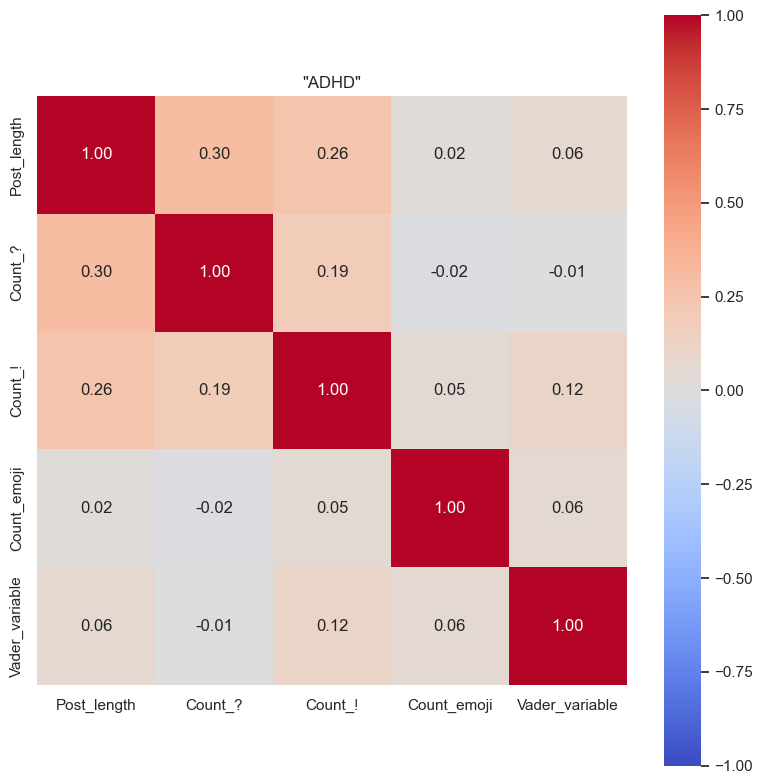

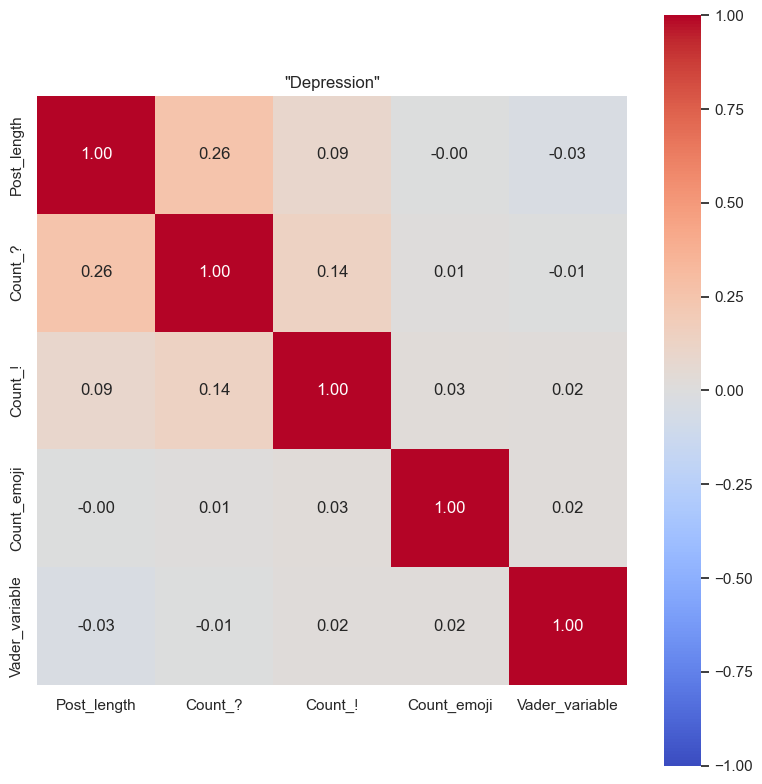

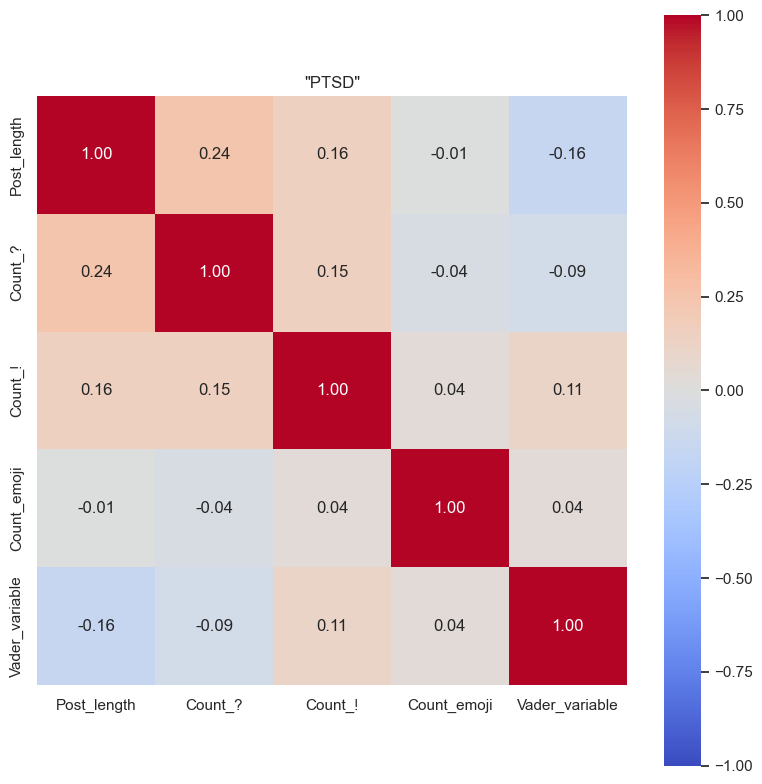

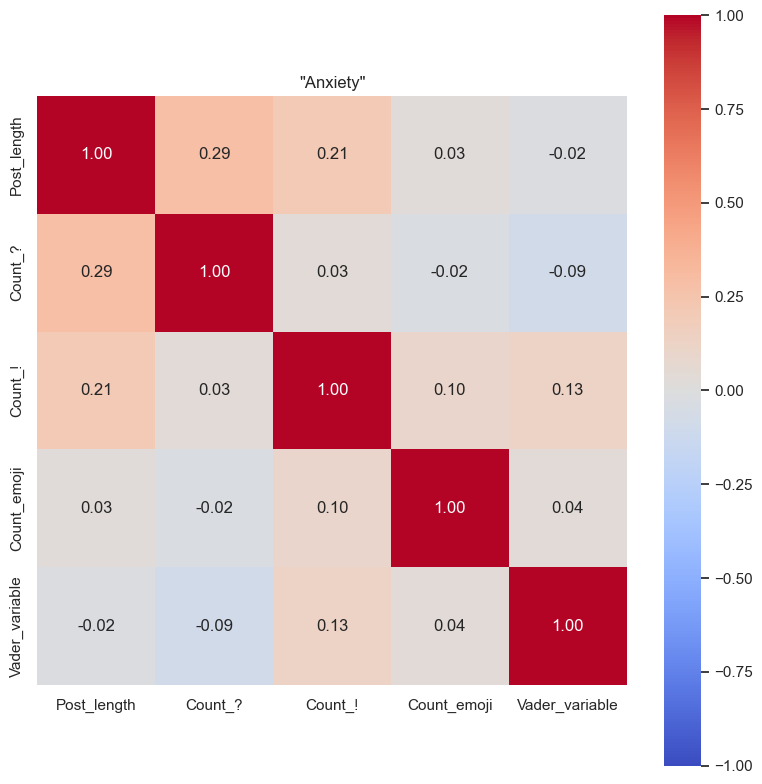

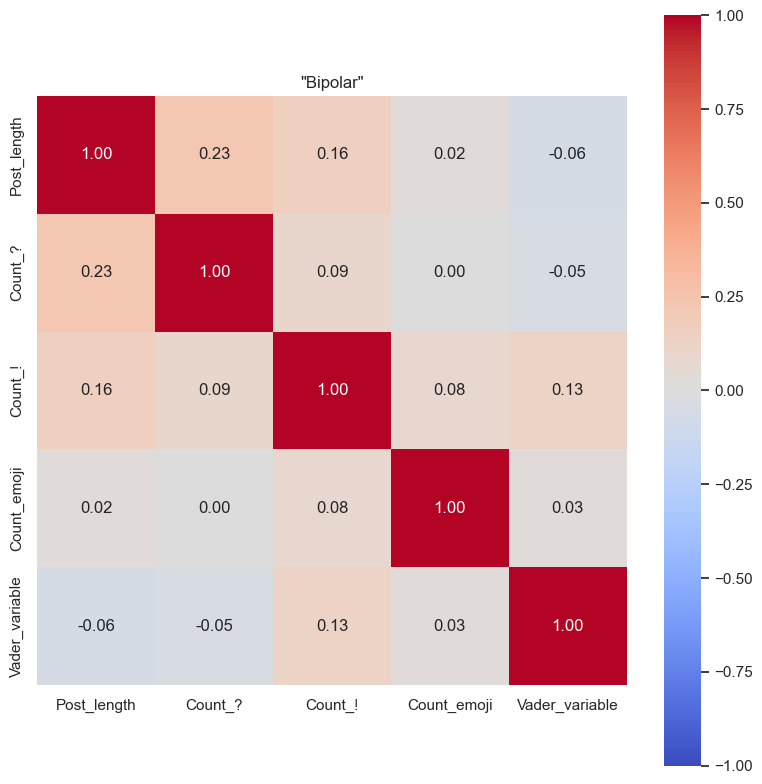

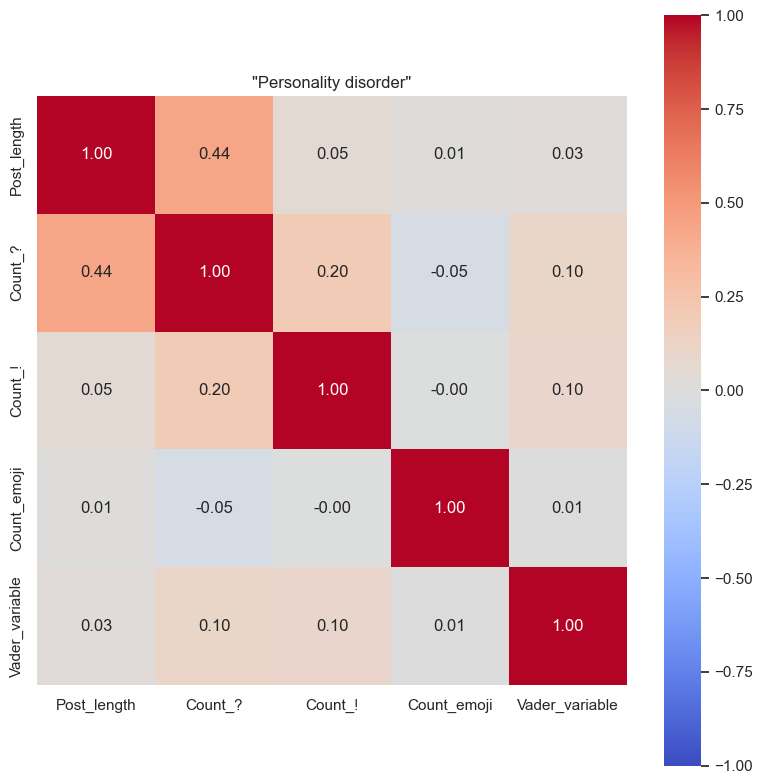

In [ ]:
for label in unique_labels:
    subset_df = cleaned_df[cleaned_df['label'] == label]
    
    # Calculate the correlation matrix for each lable
    numeric_cols = ['Post_length','Count_?','Count_!','Count_emoji','Vader_variable']
    corr_matrix = subset_df[numeric_cols].corr()
    
    plt.figure(figsize=(8, 8))
    
    # Heatmap
    sb.heatmap(
        corr_matrix, 
        annot=True,          
        cmap='coolwarm',     # Blue for negative, red for positive
        vmin=-1, vmax=1,     # create scale from -1 to 1
        square=True, 
        fmt='.2f',           # Round to 2 decimal places
        annot_kws={"size": 12}
    )
    
    plt.title(f'"{label}"')
    plt.tight_layout()
    plt.show()

## HEAT MAP ANALYSIS
as we compare length use of Punctuation and VADER score we can realise following point:

- As users write longer posts, they naturally ask more questions. They aren't just writing diary entries; they are actively seeking advice, clarity, or reassurance from the community.
- The **Personality Disorder** correlation here is 0.44—the highest single number across all six images! This means users in this specific forum are highly prone to asking strings of questions when they write long posts (e.g., trying to figure out social dynamics, asking "Why did they do this?", "Am I the problem?", etc.).
- For ADHD (0.26) and Anxiety (0.21), the correlation is distinctly positive. When these users write long posts, they are highly animated, using lots of exclamation points to express excitement, urgency, or panic, While Depression (0.09) and Personality Disorder (0.05). These numbers are basically zero. This is a brilliant clinical insight: when severely depressed users write massive 2,000-word essays, they almost entirely stop using exclamation points. The text becomes a flat, exhausted stream of words.
- The count for emojis doesnt truly demonstrate any form of connection or influence of disorder in user texts so its not found useful
- Even with punctuation added, a post with 50 exclamation points isn't mathematically guaranteed to be highly positive or highly negative.
